# Processing Strategy

## Data Characteristics
The dataset contains multiple records for the same customer across different time periods(2018 and 2019), indicating a panel data structure.
Each customer is identified by a unique ID, but appears multiple times due to yearly observations.

## Preprocessing Strategy
1) Handling Duplicate Customers
Since each customer appears multiple times, we transformed the dataset into single-record-per-customer format. To achieve this, we kept the most recent record for each customer based on the Year variable.
2) Missing values in numerical columns were imputed using the median to reduce the impact of outliers. For categorical variables, missing values were filled using the mode(most frequent value).
3) Removing Unnecessary Columns
Identifier columns such as CLIENTNUM were remeved as they do not contribute to predictive modeling. The Date_Leave column was also excluded due to its inconsistency and limited relevance to the modeling objective.
4) Final Dataset Structure
The final dataset contains one record per customer, with cleaned and consistent variables suitable for machine learning models.

In [1]:
import sys
import os
sys.path.append(os.path.abspath(".."))
import pandas as pd

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns
df = pd.read_excel("../data/raw/credit_card_og.xlsx")
print(df.shape)
df.head()

(20071, 21)


,CLIENTNUM,Attrition_Flag,Customer_Age,Gender,Dependent_count,Education_Level,Marital_Status,Income_Category,Card_Category,Months_on_book,...,Months_Inactive_12_mon,Contacts_Count_12_mon,Credit_Limit,Total_Revolving_Bal,Avg_Open_To_Buy,Total_Trans_Ct,Avg_Utilization_Ratio,Quarter,Year,Date_Leave
0,712672083,Existing Customer,65,F,0,High School,Married,Less than $40K,Blue,36,...,3,2,1438.3,747,691.3,24,0.519,none,2018,"none,2018"
1,713049933,Existing Customer,47,F,1,Graduate,Married,$40K - $60K,Silver,36,...,2,2,5756.0,0,5756.0,44,0.000,none,2018,"none,2018"
2,713049933,Existing Customer,48,F,1,Graduate,Married,$40K - $60K,Silver,48,...,6,2,5756.0,990,5756.0,25,0.170,none,2019,"none,2019"
3,713135883,Existing Customer,65,F,0,College,Married,Less than $40K,Blue,65,...,5,0,4315.0,393,3598.0,73,0.090,none,2019,"none,2019"
4,713135883,Existing Customer,64,F,0,College,Married,Less than $40K,Blue,53,...,3,0,4315.0,717,3598.0,51,0.166,none,2018,"none,2018"


# 1. Duplicate customers

In [3]:
# how many total rows and unique customers
print("Total rows:", len(df))
print("Unique customers:", df["CLIENTNUM"].nunique())

# customers that appear more than once
duplicate_counts = df["CLIENTNUM"].value_counts()
duplicate_customers = duplicate_counts[duplicate_counts > 1]

print("Number of customers with duplicate records:", len(duplicate_customers))
duplicate_customers.head(10)

Total rows: 20071
Unique customers: 11571
Number of customers with duplicate records: 8500


CLIENTNUM
712672083    2
713049933    2
713135883    2
713220258    2
713246208    2
713536158    2
713650683    2
713757633    2
713827383    2
713956308    2
Name: count, dtype: int64

* Observation: The dataset contains repeated customer IDs, which means some customers appear multiple times across different years.
* Interpretation:
This indicates a panel structure rather than a single-record-per-customer dataset.

# 2. Missing values

In [4]:
missing_values = df.isnull().sum()
missing_values[missing_values > 0].sort_values(ascending=False)

missing_percent = (df.isnull().sum() / len(df)) * 100
missing_summary = pd.DataFrame({
    "missing_count": df.isnull().sum(),
    "missing_percent": missing_percent
})
missing_summary[missing_summary["missing_count"] > 0].sort_values("missing_percent", ascending=False)


,missing_count,missing_percent


No missing values were found in the dataset, indicating that the data is complete and does not require imputation.

# 3. Outliers

Index(['CLIENTNUM', 'Customer_Age', 'Dependent_count', 'Months_on_book',
       'Total_Relationship_Count', 'Months_Inactive_12_mon',
       'Contacts_Count_12_mon', 'Credit_Limit', 'Total_Revolving_Bal',
       'Avg_Open_To_Buy', 'Total_Trans_Ct', 'Avg_Utilization_Ratio', 'Year'],
      dtype='str')


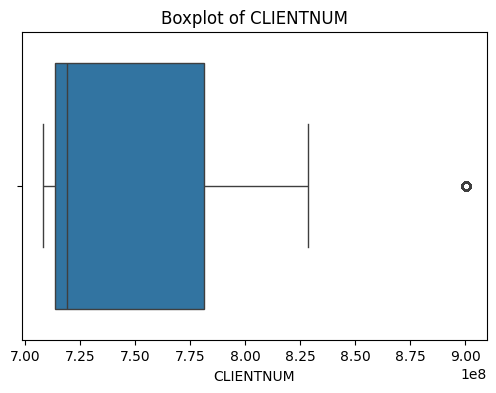

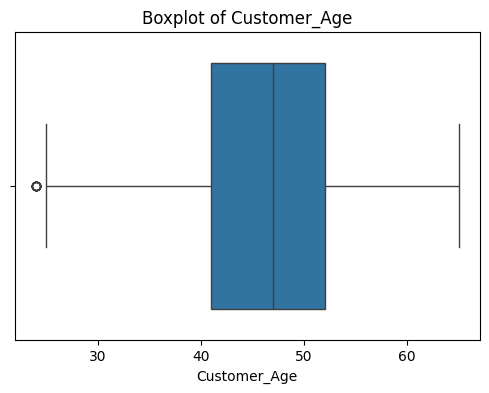

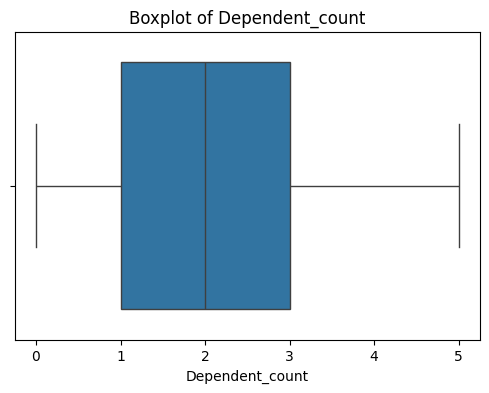

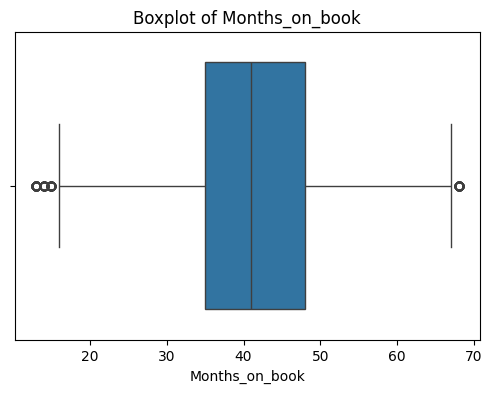

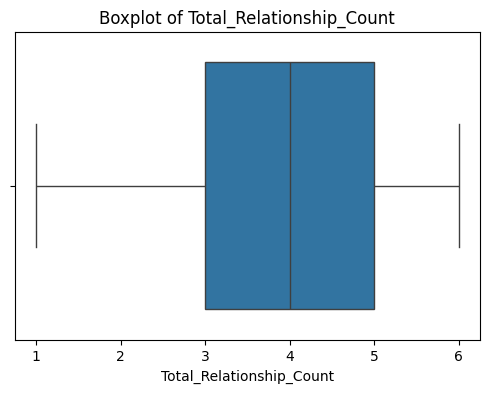

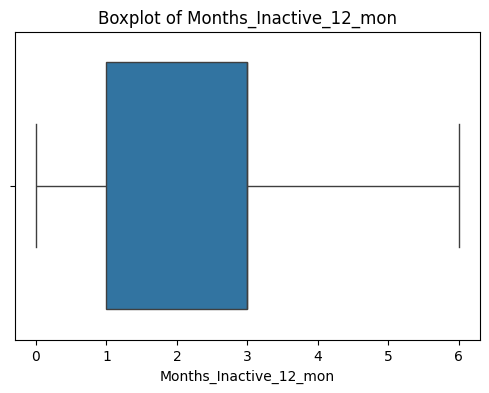

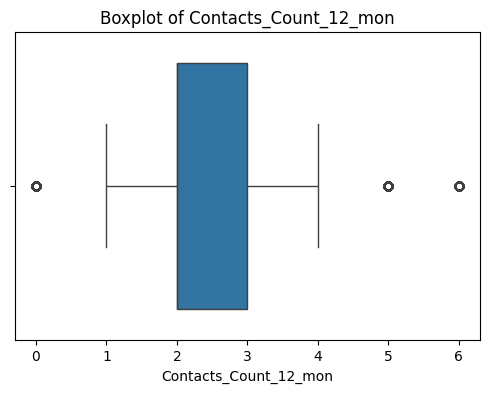

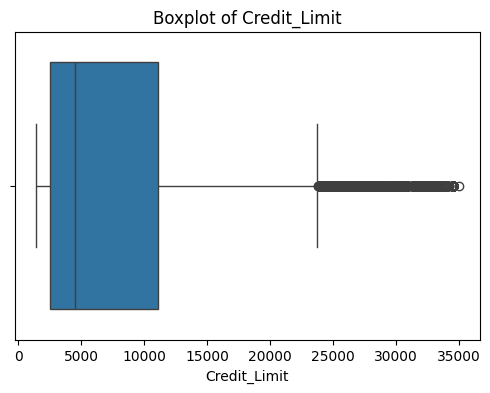

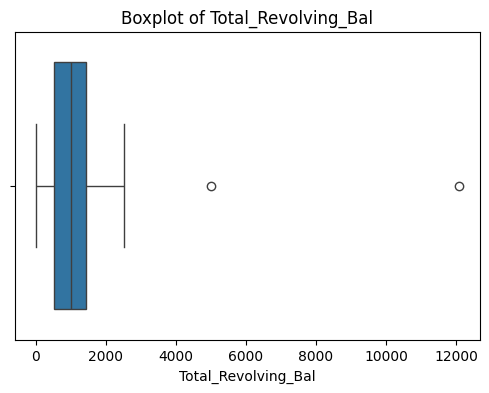

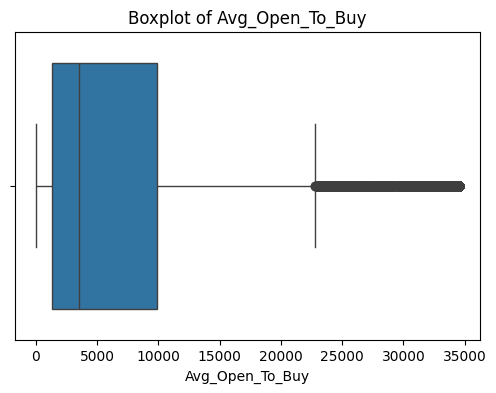

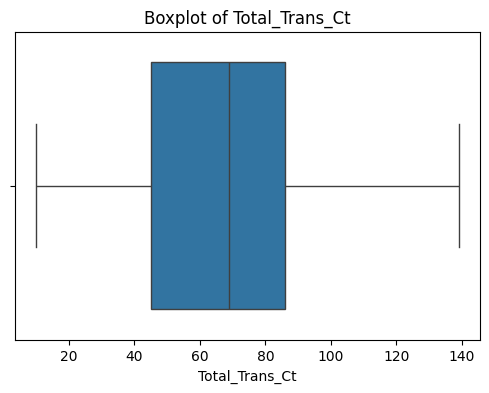

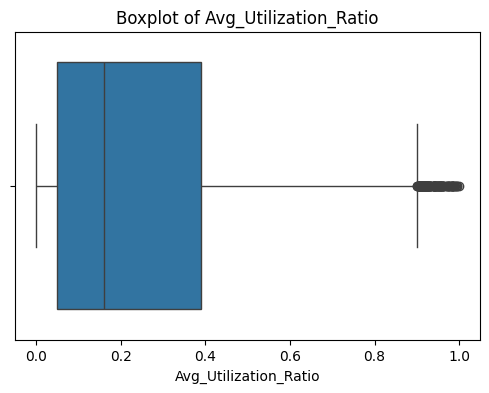

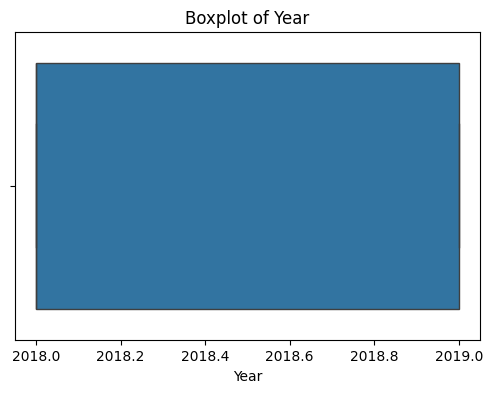

In [5]:
numeric_cols = df.select_dtypes(include=["int64", "float64"]).columns
print(numeric_cols)

key_numeric_cols = ['CLIENTNUM', 'Customer_Age', 'Dependent_count', 'Months_on_book',
       'Total_Relationship_Count', 'Months_Inactive_12_mon',
       'Contacts_Count_12_mon', 'Credit_Limit', 'Total_Revolving_Bal',
       'Avg_Open_To_Buy', 'Total_Trans_Ct', 'Avg_Utilization_Ratio', 'Year']

for col in key_numeric_cols:
    plt.figure(figsize=(6,4))
    sns.boxplot(x=df[col])
    plt.title(f"Boxplot of {col}")
    plt.show()

In [6]:
outlier_summary = {}

for col in key_numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = ((df[col] < lower) | (df[col] > upper)).sum()
    outlier_summary[col] = outliers

pd.Series(outlier_summary).sort_values(ascending=False)

Credit_Limit                1952
Avg_Open_To_Buy             1895
CLIENTNUM                   1444
Contacts_Count_12_mon       1239
Months_on_book               295
Avg_Utilization_Ratio        114
Customer_Age                  10
Total_Revolving_Bal            2
Dependent_count                0
Total_Relationship_Count       0
Months_Inactive_12_mon         0
Total_Trans_Ct                 0
Year                           0
dtype: int64



*   Observation:
Several numerical variables, such as Credit Limit and Avg Open To Buy, show a large number of extreme values.
*  Interpretation:
“These values likely reflect genuine differences in customer financial profiles rather than data errors.
* Decision:
Therefore, no outlier removal was performed to preserve important information.


# 4. Unnecessary columns

In [7]:
df.columns.tolist()

['CLIENTNUM',
 'Attrition_Flag',
 'Customer_Age',
 'Gender',
 'Dependent_count',
 'Education_Level',
 'Marital_Status',
 'Income_Category',
 'Card_Category',
 'Months_on_book',
 'Total_Relationship_Count',
 'Months_Inactive_12_mon',
 'Contacts_Count_12_mon',
 'Credit_Limit',
 'Total_Revolving_Bal',
 'Avg_Open_To_Buy',
 'Total_Trans_Ct',
 'Avg_Utilization_Ratio',
 'Quarter',
 'Year',
 'Date_Leave']

In [8]:
df[["CLIENTNUM","Date_Leave"]].head()

,CLIENTNUM,Date_Leave
0,712672083,"none,2018"
1,713049933,"none,2018"
2,713049933,"none,2019"
3,713135883,"none,2019"
4,713135883,"none,2018"


* Decision:
Therefore, no outlier removal was performed to preserve important information.
* Observation:
Some columns, such as customer identifiers and irregular date-related fields, may not contribute meaningful predictive information.

# 5. Preprocessing

In [9]:
# Remove duplicates
df = df.drop_duplicates()

# Remove ID column (not useful for prediction)
if "CLIENTNUM" in df.columns:
    df = df.drop("CLIENTNUM", axis=1)

print(df.shape)

(20071, 20)


In [10]:
y = df["Attrition_Flag"]

# Convert to numeric
y = y.map({
    "Existing Customer": 0,
    "Attrited Customer": 1
})

# Remove target from features
X = df.drop("Attrition_Flag", axis=1)

In [11]:
leakage_cols = [
    "Months_Inactive_12_mon",
    "Contacts_Count_12_mon"
]

X = X.drop(columns=[col for col in leakage_cols if col in X.columns])

print("Remaining columns:", X.columns)

Remaining columns: Index(['Customer_Age', 'Gender', 'Dependent_count', 'Education_Level',
       'Marital_Status', 'Income_Category', 'Card_Category', 'Months_on_book',
       'Total_Relationship_Count', 'Credit_Limit', 'Total_Revolving_Bal',
       'Avg_Open_To_Buy', 'Total_Trans_Ct', 'Avg_Utilization_Ratio', 'Quarter',
       'Year', 'Date_Leave'],
      dtype='str')


In [12]:
X = pd.get_dummies(X, drop_first=True)
print("Shape after encoding:", X.shape)

Shape after encoding: (20071, 38)


In [13]:
clean_df = X.copy()
clean_df["target"] = y

os.makedirs("../data/processed", exist_ok=True)
clean_df.to_csv("../data/processed/clean_data.csv", index=False)

print("Clean dataset saved!")

Clean dataset saved!
